In [1]:
ROLE  = "relay"
import os,time, pymongo ,copy
import pymongo.collection
import matplotlib.pyplot as plt
import numpy as np
import hmac


import sys
sys.path.append('../../')
import src


[INFO] [UHD] linux; GNU C++ version 13.3.0; Boost_108300; UHD_4.7.0.0-149-g635ad362
[INFO] [B200] Detected Device: B210
[INFO] [B200] Operating over USB 3.
[INFO] [B200] Initialize CODEC control...
[INFO] [B200] Initialize Radio control...
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Performing register loopback test... 
[INFO] [B200] Register loopback test passed
[INFO] [B200] Setting master clock rate selection to 'automatic'.
[INFO] [B200] Asking for clock rate 16.000000 MHz... 
[INFO] [B200] Actually got clock rate 16.000000 MHz.
[INFO] [B200] Asking for clock rate 32.000000 MHz... 
[INFO] [B200] Actually got clock rate 32.000000 MHz.
[INFO] [B200] Asking for clock rate 40.000000 MHz... 
[INFO] [B200] Actually got clock rate 40.000000 MHz.


[RELAY RX] Connected. Subscribing to 'mkashani/feeds/begin'
[RELAY RX] Publishing 'ready' for phase 1
[RELAY RX] Received 'begin'

 Recorded Time: 4.070305109024048


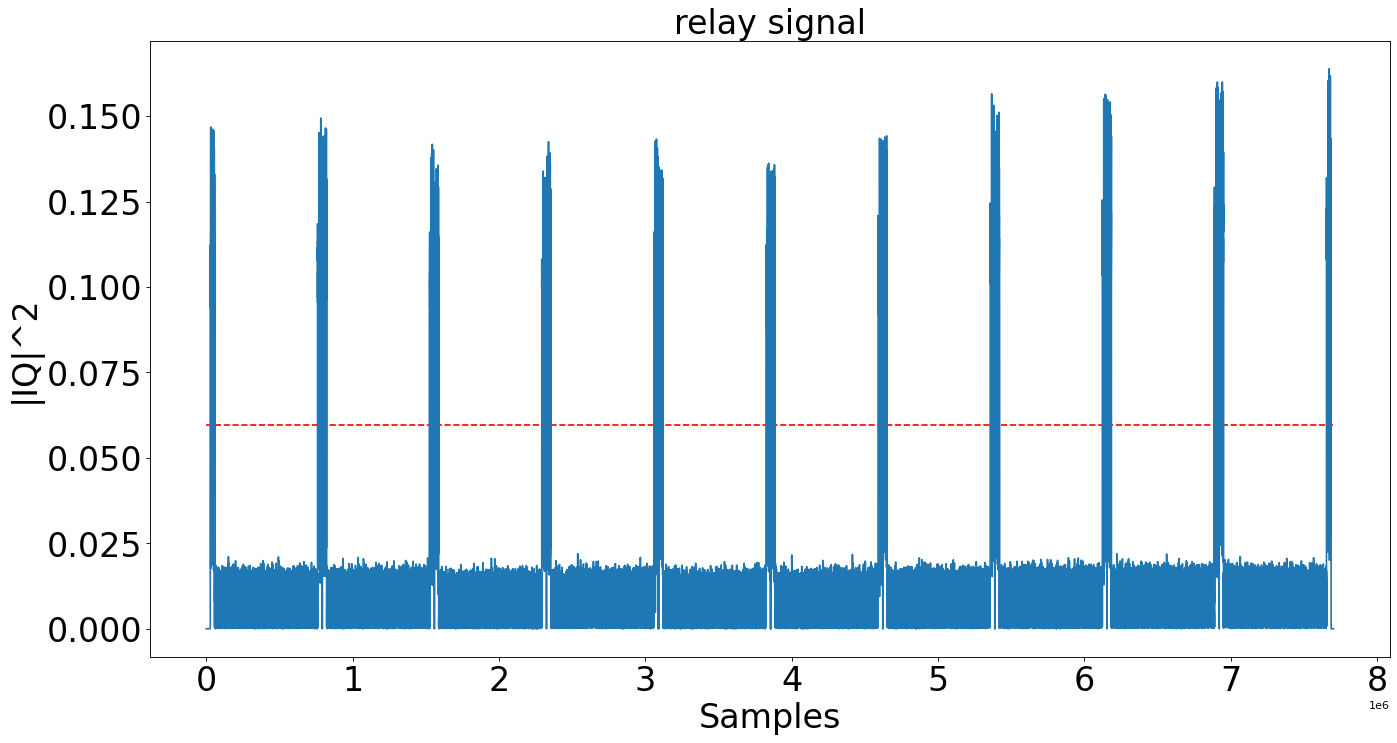


number of frames: 10
# Frame OK ...

file size is: 159989760
Size check failed ...    
Recording is correct
Message:  Ôhis message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?
MAC is not correct
SNR:  7.762972
Message:  Ôhis message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?
MAC is not correct


In [ ]:
def record(conf, ROLE ,phase):
    if src.MQTT_RX(conf=conf, role=ROLE, phase=phase, verbose=1).send_ready_and_wait_for_begin():
        file = rx.record()
        return file
    else:
        print("failed synchronization")
        return None

def process(file:str, conf:src.CONFIG, ROLE:str, collection:pymongo.collection.Collection): 
    demod = src.rx.Demodulation(conf=conf)
    pp = src.PostProcessing(file=file, conf=conf, demod=demod, role=ROLE, plot=1)

    if pp.check():
        print("Recording is correct")
        for i in range(len(pp.Frames)):
            frame = pp.frameByNumber(i)
            hard_decision,rs, SNR = demod.decode(frame)
            index = demod.detect_message_indices(received=list(hard_decision), preamble=conf.PREAMBLE, repeat=conf.PREAMBLE_REPEAT)
            if index[0] is None or index[1] is None:
                print("No preamble detected!")
                continue

            msg_hard_decision = hard_decision[index[0]:index[1]]
            print("Message: ", pp.bits_to_string(msg_hard_decision[0:-256]))
            # print("recieved MAC: ", pp.binary_list_to_hex(msg_hard_decision[-256:]))
            expected_MAC = hmac.new(conf.MAC_KEY.encode('utf-8'), msg=pp.bits_to_string(msg_hard_decision[0:-256]).encode('utf-8'), digestmod='sha256').hexdigest()
            if pp.binary_list_to_hex(msg_hard_decision[-256:]) == expected_MAC:
                print("Good MAC")
                mac = True
            else:
                print("MAC is not correct")
                mac = False

            SNR = SNR[index[0]+10:index[1]-10]
            print("SNR: ", np.nanmean(SNR))

            insert={
                'SNR': float(np.nanmean(SNR)),
                'MAC': pp.binary_list_to_hex(msg_hard_decision[-256:]),
                'message': pp.bits_to_string(msg_hard_decision[0:-256]),
                'integrity': mac,
                'time': time.time(),
                'config': copy.deepcopy(conf.config)
            }
            collection.insert_one(insert)


def tx(conf:src.CONFIG, ROLE:str, phase:int = 2):
    tx = src.TX(role=ROLE, conf=conf)

    MAC_bits = tx.hex_to_binary_list(hmac.new(tx.conf.MAC_KEY.encode(), conf.PAYLOAD.encode(), 'sha256').hexdigest())
    payload = tx.string_to_bits(tx.conf.PAYLOAD)
    fsk_signal = tx.fsk_modulate(np.concatenate([payload, MAC_bits]), # sends with half the power,
                    # mac = self.MAC_bits,
                    # alpha = self.conf.ALPHA,
                    sps = tx.conf.TX_SPS, 
                    preamble = np.concatenate([ [0 for _ in range(1000//conf.TX_SPS)] , conf.PREAMBLE]), 
                    postamble = np.concatenate([conf.PREAMBLE, [0 for _ in range(1000//conf.TX_SPS)]]),
                    scale = conf.TX_PAYLOAD_POWER_SCALE # send the payload with half the power of the preamble
                    )
    if src.MQTT_TX(conf=conf, role=ROLE, phase=phase, verbose=1).wait_for_all_ready(sleep_time=0.5):
        for i in range(10):
            tx.send_waveform(fsk_signal)
            time.sleep(0.1)
        return True
    else:
        print("failed synchronization")
        return False






conf = src.CONFIG()

if conf.connectionString is None:
    print("No connection string provided")
    exit(1)

if conf.MQTT is None:
    print("No MQTT broker provided")
    exit(1)


rx = src.RX(role=ROLE,conf=conf)
myclient = pymongo.MongoClient(conf.connectionString)
mydb = myclient["MAC_1D"]

while True:
    phase = 1
    file = record(conf=conf, ROLE=ROLE, phase=phase)
    if file is None:
        continue
    process(file=file, conf=conf, ROLE=ROLE, collection=mydb[f'{ROLE}, phase_{phase}'])

    phase = 2
    
    if not tx(conf=conf, ROLE=ROLE, phase=phase):
        print(f"failed synchronization {ROLE}, phase_{phase}")
        continue
